In [1]:
from sklearn.preprocessing import StandardScaler

import joblib

# Load scaler later
scaler = joblib.load('/work/y_scaler_f_correct.pkl')

In [4]:
import pandas as pd 
from sklearn.model_selection import train_test_split

X = pd.read_csv("/work/X_full_scale.csv", index_col=0)
y = pd.read_csv("/work/y_f_correct_scale.csv", index_col=0)
# X = X.drop("DS", axis=1)
# X = X.drop("DPR", axis=1)
# X = X.drop("STR", axis=1)
# X = X.drop("MKT", axis=1)
# X = X.drop("SPX Index - Volume", axis=1)
# X = X.drop("Jump", axis=1)
# X = X.drop("VIX_div_RV_day", axis=1)
# X = X.drop("RV_week_div_RV_month", axis=1)
# X = X.drop("jump_x_VIX", axis=1)
# X = X.drop("RV_day_x_volume", axis=1)
# X = X.drop("VIX_x_MKT", axis=1)
# X = X.drop("realized_skew", axis=1)
# X = X.drop("realized_kurt", axis=1)
# X = X.drop("vix_term_relative", axis=1)
# X = X.drop("vix_term_ratio", axis=1)
# X = X.drop("RV_month", axis=1)
# X = X.drop("RV_week", axis=1)
# X = X.drop("RV_day", axis=1)
# X = X.drop("VIX", axis=1)

#start_date = '2018-05-20'
#end_date = '2020-09-30'

#X = X.loc[start_date:end_date]
#y = y.loc[start_date:end_date]

# X = X[1383:]
# y = y[1383:]

In [7]:
len(y)


2765

In [10]:
# Correcting the syntax error in the provided code

# Install necessary libraries
!pip install statsmodels
!pip install xgboost==3.0.2
!pip install POT

# Importing the statsmodels library
import statsmodels.api as sm


[notice] A new release of pip is available: 23.0.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.9/253.9 MB 3.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.3/322.3 MB 2.2 MB/s eta 0:00:00

[notice] A new release of pip is available: 23.0.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 865.6/865.6 kB 71.3 MB/s eta 0:00:00

[notice] A new release of pip is available: 23.0.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip


In [13]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.cluster import SpectralClustering
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier
from scipy.stats import mood
import ot  # POT library for optimal transport

def mood_segmentation(y, window=5, alpha=0.05):
    change_points = []
    for t in range(window, len(y) - window):
        left = y[t - window:t]
        right = y[t:t + window]
        stat, p = mood(left, right)
        if p < alpha:
            change_points.append(t)
    return sorted(set(change_points))

def segment_wasserstein(seg1, seg2):
    n1 = seg1.shape[0]
    n2 = seg2.shape[0]
    a, b = np.ones((n1,)) / n1, np.ones((n2,)) / n2
    M = ot.dist(seg1, seg2, metric='euclidean')
    W = ot.emd2(a, b, M)
    return np.sqrt(W)

def rolling_markov_mood_spec_xgb_har(X, y, features,
                                     n_clusters=3,
                                     train_days=441,
                                     predict_days=5,
                                     mood_window=5,
                                     mood_alpha=0.05,
                                     xgb_param_dist=None,
                                     xgb_tuning_iter=25):
    if isinstance(y, pd.Series):
        y = y.values
    if not isinstance(X, pd.DataFrame):
        raise ValueError("X must be a DataFrame with named columns.")

    n = len(y)
    predictions = []
    prediction_indices = []
    test_cluster_labels_all = []  # <-- added to store test cluster labels

    if xgb_param_dist is None:
        xgb_param_dist = {
            "n_estimators": [50, 100, 150],
            "max_depth": [3, 4, 5],
            "learning_rate": [0.01, 0.05, 0.1],
            "subsample": [0.7, 0.8, 1.0],
            "colsample_bytree": [0.7, 0.8, 1.0]
        }

    start = 0
    while start + train_days < n:
        current_predict_days = min(predict_days, n - (start + train_days))

        X_train_df = X.iloc[start:start + train_days].copy()
        y_train = y[start:start + train_days]
        X_test_df = X.iloc[start + train_days:start + train_days + current_predict_days].copy()
        y_test = y[start + train_days:start + train_days + current_predict_days]

        if X_train_df.isnull().any().any() or np.isnan(y_train).any() or X_test_df.isnull().any().any():
            print(f"Skipping window at index {start} due to NaNs.")
            start += predict_days
            continue

        change_points = mood_segmentation(y_train, window=mood_window, alpha=mood_alpha)
        change_points = [0] + change_points + [len(y_train)]

        segments = [np.hstack((
            X_train_df.iloc[change_points[i]:change_points[i+1]][features].values,
            y_train[change_points[i]:change_points[i+1]].reshape(-1, 1)
        )) for i in range(len(change_points)-1)]

        n_segments = len(segments)
        W_dist = np.zeros((n_segments, n_segments))
        for i in range(n_segments):
            for j in range(i+1, n_segments):
                dist = segment_wasserstein(segments[i], segments[j])
                W_dist[i, j] = W_dist[j, i] = dist

        sigma = np.median(W_dist[W_dist > 0])
        if sigma == 0 or np.isnan(sigma):
            sigma = 1e-5

        W_sim = np.exp(-W_dist ** 2 / (2 * sigma ** 2))

        clustering = SpectralClustering(n_clusters=n_clusters, affinity='precomputed', random_state=24)
        segment_labels = clustering.fit_predict(W_sim)

        point_labels_train = np.empty(len(y_train), dtype=int)
        for i, label in enumerate(segment_labels):
            start_idx = change_points[i]
            end_idx = change_points[i + 1]
            point_labels_train[start_idx:end_idx] = label

        xgb_clf = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
        random_search = RandomizedSearchCV(
            xgb_clf,
            xgb_param_dist,
            n_iter=xgb_tuning_iter,
            cv=3,
            verbose=0,
            n_jobs=-1,
            random_state=24,
            scoring='neg_log_loss'
        )
        random_search.fit(X_train_df[features], point_labels_train)
        best_xgb = random_search.best_estimator_

        point_labels_test = best_xgb.predict(X_test_df[features])
        test_cluster_labels_all.append(point_labels_test)  # <-- store test cluster labels

        cluster_har_models = {}
        for cluster in range(n_clusters):
            idx = (point_labels_train == cluster)
            if not np.any(idx):
                continue
            X_cluster = X_train_df.loc[idx, features]
            y_cluster = y_train[idx]
            X_cluster_const = sm.add_constant(X_cluster, has_constant='add')
            model = sm.OLS(y_cluster, X_cluster_const).fit()
            cluster_har_models[cluster] = model

        preds = np.empty(current_predict_days)
        preds[:] = np.nan

        for cluster in range(n_clusters):
            idx = (point_labels_test == cluster)
            if not np.any(idx) or cluster not in cluster_har_models:
                preds[idx] = np.nan
                continue
            X_test_cluster = X_test_df.loc[idx, features]
            X_test_const = sm.add_constant(X_test_cluster, has_constant='add')
            expected_cols = cluster_har_models[cluster].model.exog_names
            X_test_const = X_test_const.reindex(columns=expected_cols, fill_value=0)
            preds[idx] = cluster_har_models[cluster].predict(X_test_const)

        predictions.append(preds)
        prediction_indices.append(np.arange(start + train_days, start + train_days + current_predict_days))

        start += predict_days

    return (np.concatenate(predictions),
            np.concatenate(prediction_indices),
            np.concatenate(test_cluster_labels_all))  # <-- return test cluster labels


/root/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-07-04 02:18:07.145714: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-07-04 02:18:07.150042: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-07-04 02:18:07.186011: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-07-04 02:18:07.186122: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to regis

In [16]:
features = [
    "STR",
    "MKT",
    "SPX Index - Volume",
    "Jump",
    "realized_kurt",
    "vix_term_relative",
    "vix_term_ratio",
    "RV_month",
    "RV_week",
    "RV_day",
    "VIX"
]

param_dist = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': np.linspace(0.01, 0.3, 10),
    'subsample': np.linspace(0.6, 1.0, 5),
    'colsample_bytree': np.linspace(0.6, 1.0, 5),
    'gamma': [0, 0.1, 0.2, 0.3],
    'reg_alpha': [0, 0.01, 0.1, 1],
    'reg_lambda': [1, 1.5, 2, 3]
}
predictions, prediction_indices, test_cluster_labels_all = rolling_markov_mood_spec_xgb_har(
    X=X,
    y=y if isinstance(y, np.ndarray) else np.array(y),
    features=features,
    n_clusters=2,
    train_days=441,
    predict_days=1,
    xgb_param_dist=param_dist,
    xgb_tuning_iter=25
)

Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/root/venv/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [03:30:29] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/root/venv/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [03:30:29] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/root/venv/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [03:30:29] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/root/venv/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [03:30:29] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/root

In [17]:
len(predictions)

2324

In [18]:
# Convert to correct shape & evaluate
import numpy as np
import joblib
from sklearn.metrics import mean_absolute_percentage_error

# Load your scaler
scaler = joblib.load('y_scaler_f_correct_scale.pkl')


y_true = y.iloc[prediction_indices]  

# Reshape and inverse transform
y_true = scaler.inverse_transform(np.array(y_true).reshape(-1, 1))
y_pred = scaler.inverse_transform(np.array(predictions).reshape(-1, 1))

# Evaluate
mape = mean_absolute_percentage_error(y_true, y_pred)
print(f"MAPE: {mape:.6f} ({mape * 100:.2f}%)")

MAPE: 0.300458 (30.05%)


In [19]:
from sklearn.metrics import mean_squared_error, r2_score

# Load your scaler
scaler = joblib.load('y_scaler_f_correct_scale.pkl')

# True values
y_true = y.iloc[prediction_indices]

# Reshape and inverse transform
y_true = scaler.inverse_transform(np.array(y_true).reshape(-1, 1))
y_pred = scaler.inverse_transform(np.array(predictions).reshape(-1, 1))

# Compute metrics
mse = mean_squared_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

print(f"Mean Squared Error (MSE): {mse:.8f}")
print(f"R^2 Score: {r2:.8f}")


Mean Squared Error (MSE): 0.00002693
R^2 Score: 0.46963205


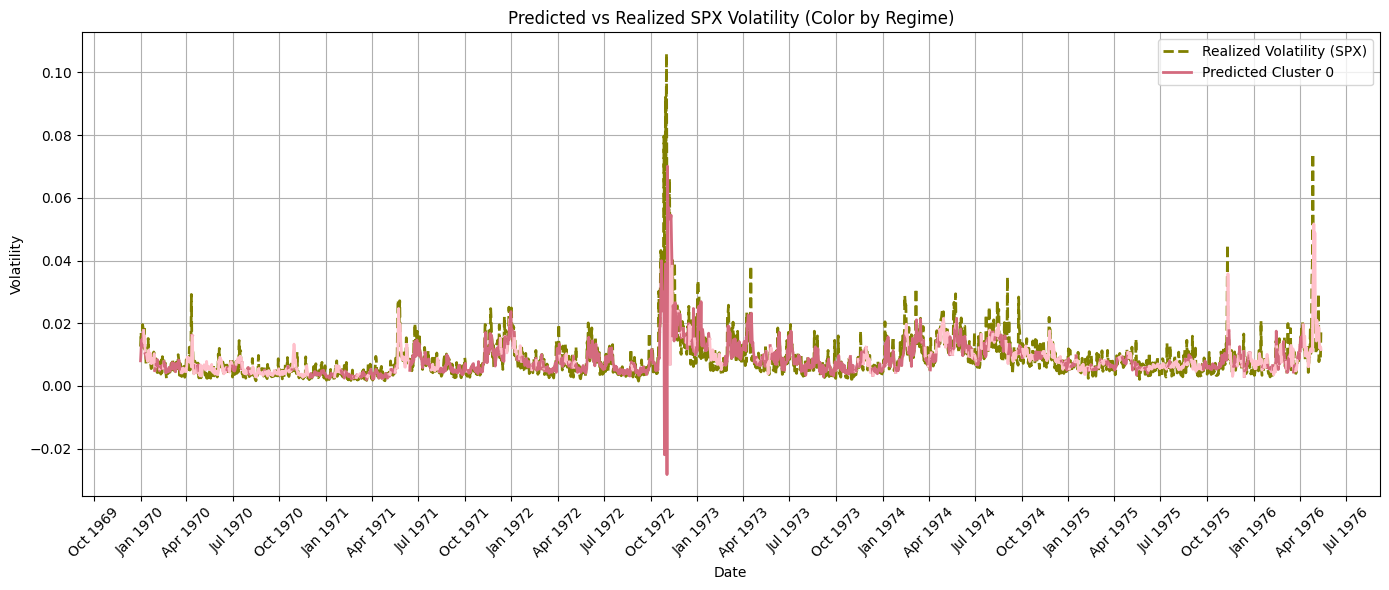

In [20]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

# Inverse transform
y_true_is = y_true
y_hat_is = scaler.inverse_transform(np.array(predictions).reshape(-1, 1))

# Flatten arrays
y_true_is = y_true_is.flatten()
y_hat_is = y_hat_is.flatten()

# Get datetime index for predictions
prediction_dates = X.iloc[prediction_indices].index

# Define color map
cluster_colors = {0: 'xkcd:pinkish', 1: 'pink', 2: 'purple'}

# Create the plot
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(prediction_dates, y_true_is, label='Realized Volatility (SPX)', linewidth=2, linestyle='dashed', color='olive')

test_cluster_labels_all = np.array(test_cluster_labels_all).flatten()

# Plot predicted volatility with color by cluster
start_idx = 0
for i in range(1, len(y_hat_is)):
    if test_cluster_labels_all[i] != test_cluster_labels_all[start_idx] or i == len(y_hat_is) - 1:
        segment_x = prediction_dates[start_idx:i + 1]
        segment_y = y_hat_is[start_idx:i + 1]
        cluster_id = test_cluster_labels_all[start_idx]
        ax.plot(segment_x, segment_y, color=cluster_colors[cluster_id], linewidth=2,
                label=f'Predicted Cluster {cluster_id}' if start_idx == 0 else "")
        start_idx = i

# Set title and labels
ax.set_title('Predicted vs Realized SPX Volatility (Color by Regime)')
ax.set_xlabel('Date')
ax.set_ylabel('Volatility')
ax.grid(True)

# Format x-axis to show selected quarterly ticks
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10], bymonthday=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)

ax.legend()
plt.tight_layout()
plt.show()

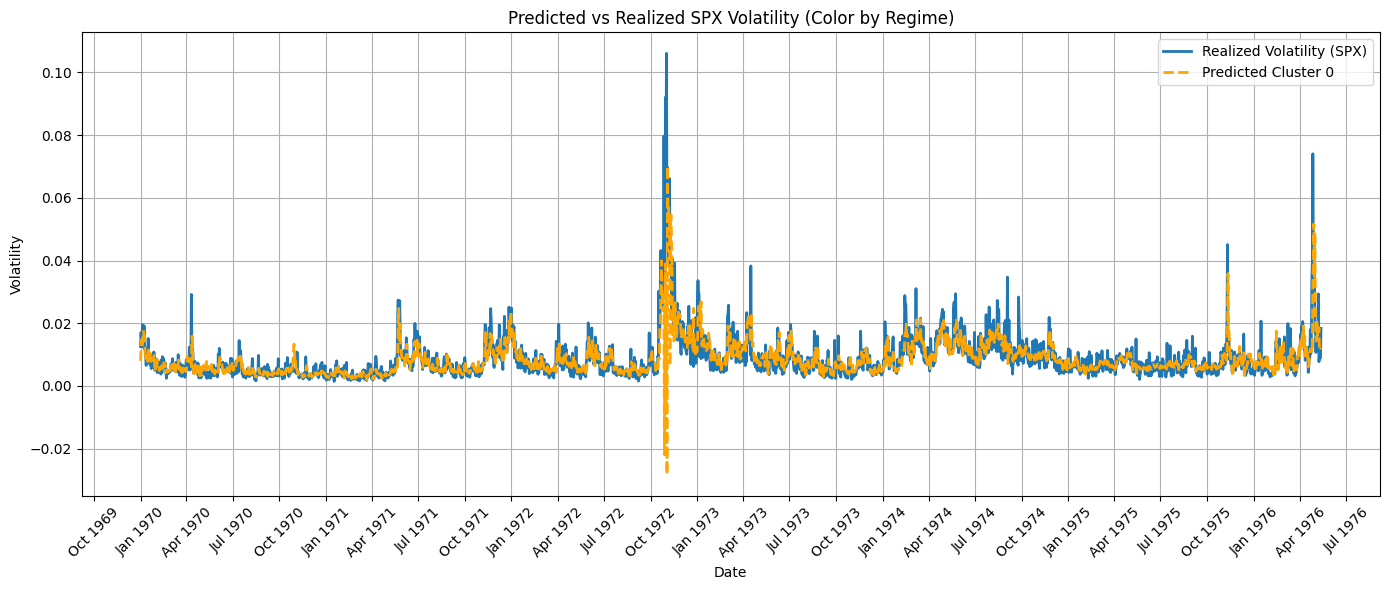

In [21]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

# Inverse transform
y_true_is = y_true
y_hat_is = scaler.inverse_transform(np.array(predictions).reshape(-1, 1))

# Flatten arrays
y_true_is = y_true_is.flatten()
y_hat_is = y_hat_is.flatten()

# Get datetime index for predictions
prediction_dates = X.iloc[prediction_indices].index

# Define color map
cluster_colors = {0: 'orange', 1: 'orange', 2: 'orange'}

# Create the plot
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(prediction_dates, y_true_is, label='Realized Volatility (SPX)', linewidth=2)

test_cluster_labels_all = np.array(test_cluster_labels_all).flatten()

# Plot predicted volatility with color by cluster
start_idx = 0
for i in range(1, len(y_hat_is)):
    if test_cluster_labels_all[i] != test_cluster_labels_all[start_idx] or i == len(y_hat_is) - 1:
        segment_x = prediction_dates[start_idx:i + 1]
        segment_y = y_hat_is[start_idx:i + 1]
        cluster_id = test_cluster_labels_all[start_idx]
        ax.plot(segment_x, segment_y, color=cluster_colors[cluster_id], linewidth=2, linestyle='dashed',
                label=f'Predicted Cluster {cluster_id}' if start_idx == 0 else "")
        start_idx = i

# Set title and labels
ax.set_title('Predicted vs Realized SPX Volatility (Color by Regime)')
ax.set_xlabel('Date')
ax.set_ylabel('Volatility')
ax.grid(True)

# Format x-axis to show selected quarterly ticks
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10], bymonthday=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)

ax.legend()
plt.tight_layout()
plt.show()

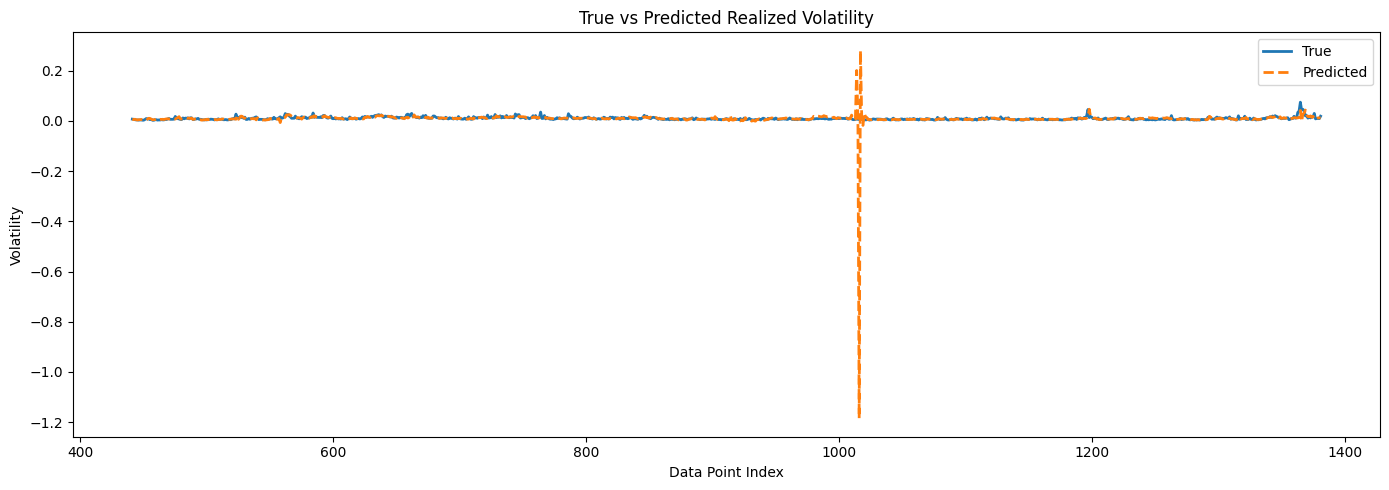

In [58]:
import matplotlib.pyplot as plt
import pandas as pd

# Step 1: Build a DataFrame using just index numbers
df_plot = pd.DataFrame({
    'Index': prediction_indices,
    'True': y_true.ravel(),
    'Predicted': y_pred.ravel()
}).set_index('Index')

# Step 2: Plot
plt.figure(figsize=(14, 5))
plt.plot(df_plot.index, df_plot['True'], label='True', linewidth=2)
plt.plot(df_plot.index, df_plot['Predicted'], label='Predicted', linewidth=2, linestyle='--')
plt.title('True vs Predicted Realized Volatility')
plt.xlabel('Data Point Index')
plt.ylabel('Volatility')
plt.legend()
plt.tight_layout()
plt.show()


In [49]:
import numpy as np

arr = np.array(y_pred)
np.save('rolling_cluster_predictions.npy', arr)

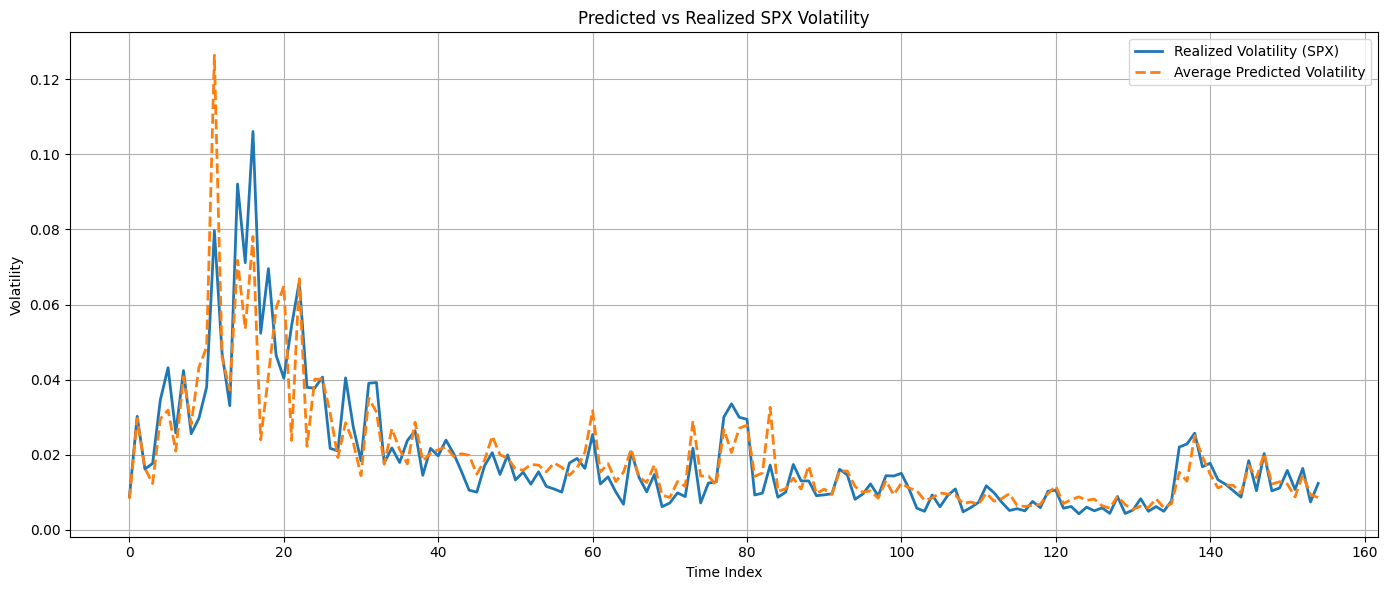

In [52]:
import matplotlib.pyplot as plt
import numpy as np

cluster_predictions = np.load('rolling_cluster_predictions_COVID_3day.npy')
markov_roll_predications = np.load('rolling_markov_XGB_COVID_3.npy')
real_values = np.load('true_COVID.npy')

avg = (cluster_predictions + markov_roll_predications) / 2

plt.figure(figsize=(14, 6))
plt.plot(real_values, label='Realized Volatility (SPX)', linewidth=2)
plt.plot(avg, label='Average Predicted Volatility', linewidth=2, linestyle='--')
plt.title('Predicted vs Realized SPX Volatility')
plt.xlabel('Time Index')
plt.ylabel('Volatility')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [194]:
from sklearn.metrics import mean_absolute_percentage_error
mape = mean_absolute_percentage_error(real_values, avg)
print("MAPE: ", mape)
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(real_values, avg)
print("MSE: ", mse)

MAPE:  0.24769467632352968
MSE:  6.338485370604345e-05


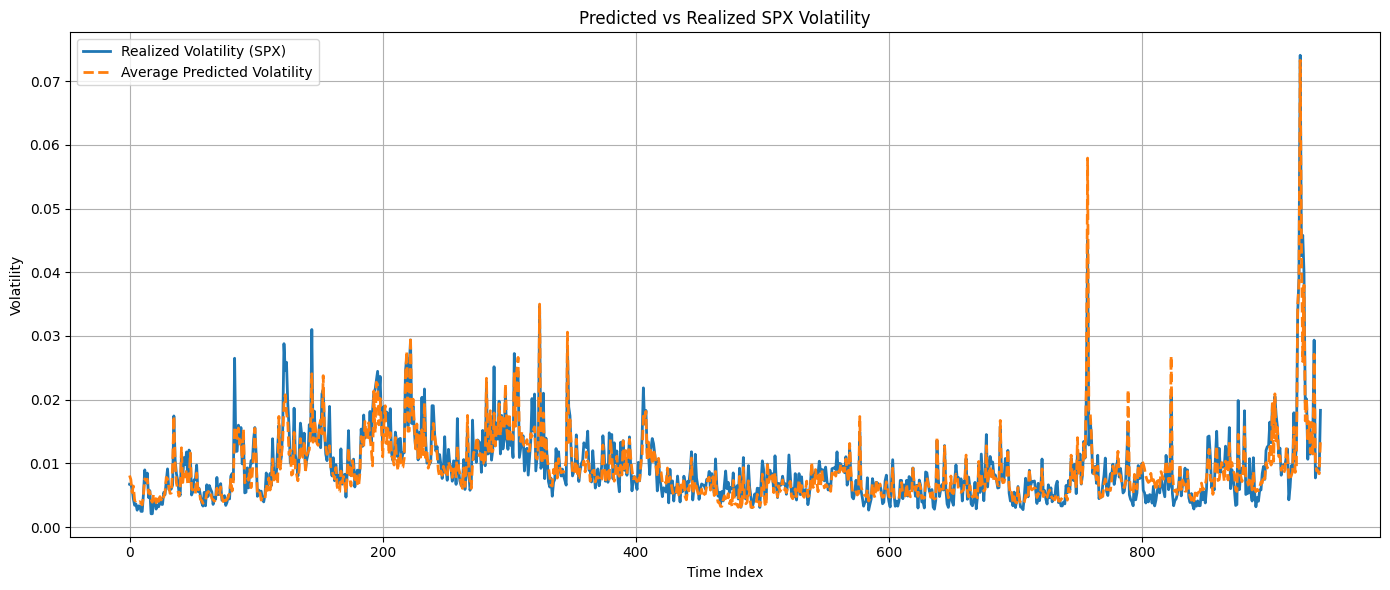

In [67]:
import matplotlib.pyplot as plt
import numpy as np

cluster_predictions = np.load('rolling_cluster_predictions.npy')
vert_predictions = np.load('vert_predictions.npy')
real_values = np.load('markov_true.npy')

avg2 = (cluster_predictions + vert_predictions) / 2

plt.figure(figsize=(14, 6))
plt.plot(real_values, label='Realized Volatility (SPX)', linewidth=2)
plt.plot(avg2, label='Average Predicted Volatility', linewidth=2, linestyle='--')
plt.title('Predicted vs Realized SPX Volatility')
plt.xlabel('Time Index')
plt.ylabel('Volatility')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [70]:
from sklearn.metrics import mean_absolute_percentage_error
mape = mean_absolute_percentage_error(real_values, avg2)
print("MAPE: ", mape)
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(real_values, avg2)
print("MSE: ", mse)

MAPE:  0.1734316717397556
MSE:  4.386385712461784e-06


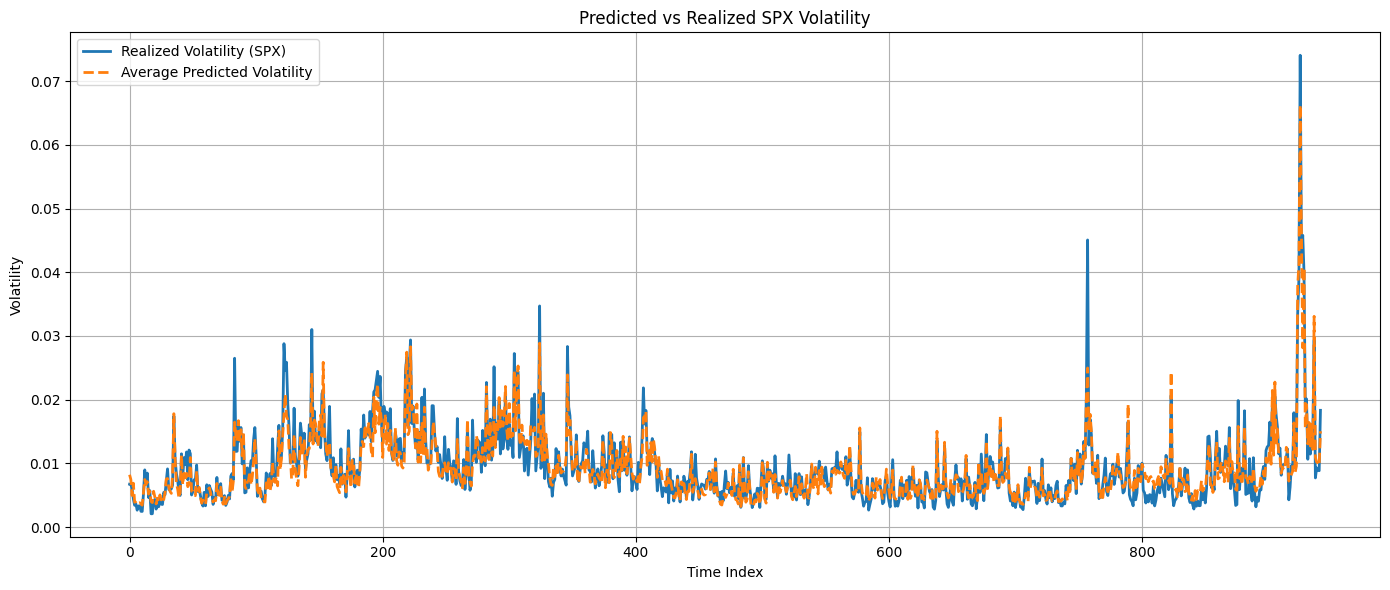

In [124]:
import matplotlib.pyplot as plt
import numpy as np

cluster_predictions = np.load('rolling_cluster_predictions.npy')
vert_predictions = np.load('vert_predictions.npy')
markov_roll_predications = np.load('rolling_markov_XGB.npy')
real_values = np.load('markov_true.npy')

avg3 = (cluster_predictions + vert_predictions + markov_roll_predications) / 3

plt.figure(figsize=(14, 6))
plt.plot(real_values, label='Realized Volatility (SPX)', linewidth=2)
plt.plot(avg3, label='Average Predicted Volatility', linewidth=2, linestyle='--')
plt.title('Predicted vs Realized SPX Volatility')
plt.xlabel('Time Index')
plt.ylabel('Volatility')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [127]:
from sklearn.metrics import mean_absolute_percentage_error
mape = mean_absolute_percentage_error(real_values, avg3)
print("MAPE: ", mape)
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(real_values, avg3)
print("MSE: ", mse)

MAPE:  0.16798043144448524
MSE:  4.517009992807032e-06


<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=c491ba08-7b0b-4e77-bbce-46de4cee5dd0' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>